In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary

from sklearn.metrics import class_likelihood_ratios, recall_score, precision_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)



In [2]:
bootstrap_columns = [f"target_bootstrap_{n}" for n in range(1000)]

# 30-day Mortality

In [3]:
combined_results = pd.read_csv(
    "pod_bootstrap_results_df.csv",
)

outcome_col = "Future Organ Dysfunction"
label_col = "future_deterioration"
title = "Persistent Organ Dysfunction"

<Axes: xlabel='Future Organ Dysfunction', ylabel='Count'>

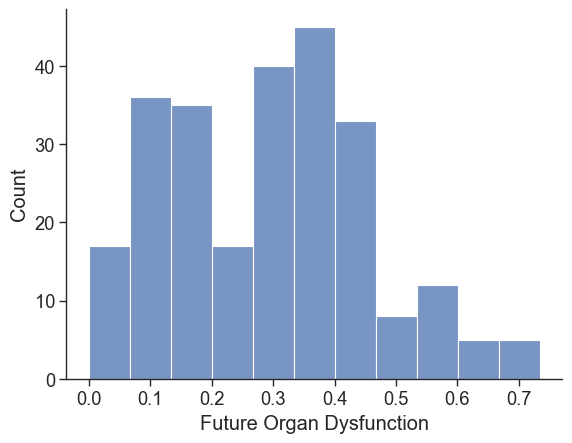

In [4]:
sns.histplot(
    data=combined_results,
    x=outcome_col,
)

In [5]:
combined_results[outcome_col].max()

0.7343000000000015

In [6]:
cutoffs = [
    0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6
]

In [7]:
bootstrapped_recalls = []
bootstrapped_aucs = []
bootstrapped_precisions = []
plr_gp = []
thresholds = []

subsample = combined_results.copy()

for col in bootstrap_columns:

    bootstrapped_recalls.append(
        recall_score(subsample[label_col], np.where(subsample[col] > 0.0, 1, 0))
    )

    bootstrapped_precisions.append(
        precision_score(subsample[label_col], np.where(subsample[col] > 0.0, 1, 0))
    )

    bootstrapped_aucs.append(
        roc_auc_score(
            subsample[label_col], subsample[col]
        )
    )

    for cutoff in cutoffs:

        plr_gp.append(
            class_likelihood_ratios(subsample[label_col], np.where(subsample[col] > cutoff, 1, 0), replace_undefined_by=1)[0]
        )
        thresholds.append(cutoff)



mort_lr_df = pd.DataFrame(
    {
        "LR+": plr_gp,
        "Cutoff": thresholds,
        "Label": [title for _ in range(len(plr_gp))],
    }
)

mort_bs_df = pd.DataFrame(
    {
        "Recall": bootstrapped_recalls,
        "AUC": bootstrapped_aucs,
        "Precision": bootstrapped_precisions,
        "Label": [title for _ in range(len(bootstrapped_recalls))],
    }
)


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Doc

In [8]:
combined_bs_df = pd.concat(
    [mort_bs_df]
)

combined_lr_df = pd.concat(
    [mort_lr_df]
)

/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_60423/2435908767.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(


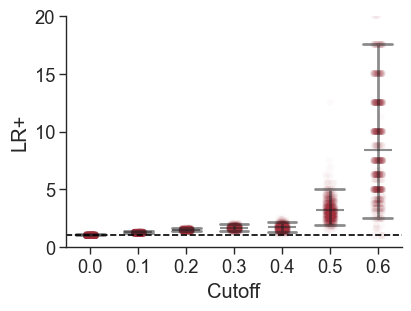

In [9]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    #width_ratios=[0.25, 1],
    constrained_layout=True,
    #sharey="row",
)

# axs = axs.ravel()
#
# sns.pointplot(
#     data=combined_bs_df,
#     x="Label",
#     y="Recall",
#     hue="Label",
#     palette='dark:k',
#     errorbar=("pi", 95),
#     marker="_",
#     markersize=20,
#     markerfacecolor="k",
#     color="k",
#     capsize=.6,
#     err_kws={"color": "k", "linewidth": 2},
#     linewidth=2,
#     legend=False,
#     ax=axs[0]
# )
#
# sns.stripplot(
#     data=combined_bs_df,
#     x="Label",
#     y="Recall",
#     #hue="Label",
#     color="#A32F3C",
#     ax=axs[0],
#     #palette="Blues",
#     linewidth=0,
#     legend=False,
#     alpha=0.02,
#
# )
#
# axs[0].set_xlabel("")
# axs[0].set_ylabel("Sensitivity")
# axs[0].set_xticklabels(
#     []
# )
# axs[0].set_xticks([])
# sns.despine(ax=axs[0], bottom=True, top=True, trim=True, offset=1)

sns.pointplot(
    data=mort_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs,
    alpha=.5,
)

sns.stripplot(
    data=mort_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs,
    color="#A32F3C",
    linewidth=0,
    legend=False,
    alpha=0.02,
    zorder=1,

)

axs.set_xlabel("Cutoff\nOrgan Dysfunction")

axs.axhline(y=1, linestyle='--', color='black')
axs.set_xticklabels(
    [f"{val:.1f}" for val in mort_lr_df['Cutoff']],
)
axs.set_ylim(0, 20)

axs.set_xlabel("Cutoff")
#axs[1].set_title("Organ Dysfunction")



fig.set_size_inches(
    (4, 3)
)

fig.savefig("pod_metrics.pdf", bbox_inches="tight", dpi=300, transparent=True)
